# 常见的激活函数
- ReLU (Rectified Linear Unit)：$f(x) = \max(0, x)$
- Sigmoid：$f(x) = \frac{1}{1 + e^{-x}}$
- Tanh (Hyperbolic Tangent)：$f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- GLU (Gated Linear Unit)：$f(x) = x \cdot \sigma(Wx + b)$
- GELU (Exponential Linear Unit)：$f(x) = \begin{cases} x, & x > 0 \\ \alpha (e^x - 1), & x \le 0 \end{cases}$
- SwiGLU (Swish Gated Linear Unit)：$f(x) = x \cdot \sigma(\beta x)$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## 1. ReLU 

In [2]:
def relu(x):
    return np.maximum(0, x)

## 2. Sigmoid

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## 3. SwiGLU

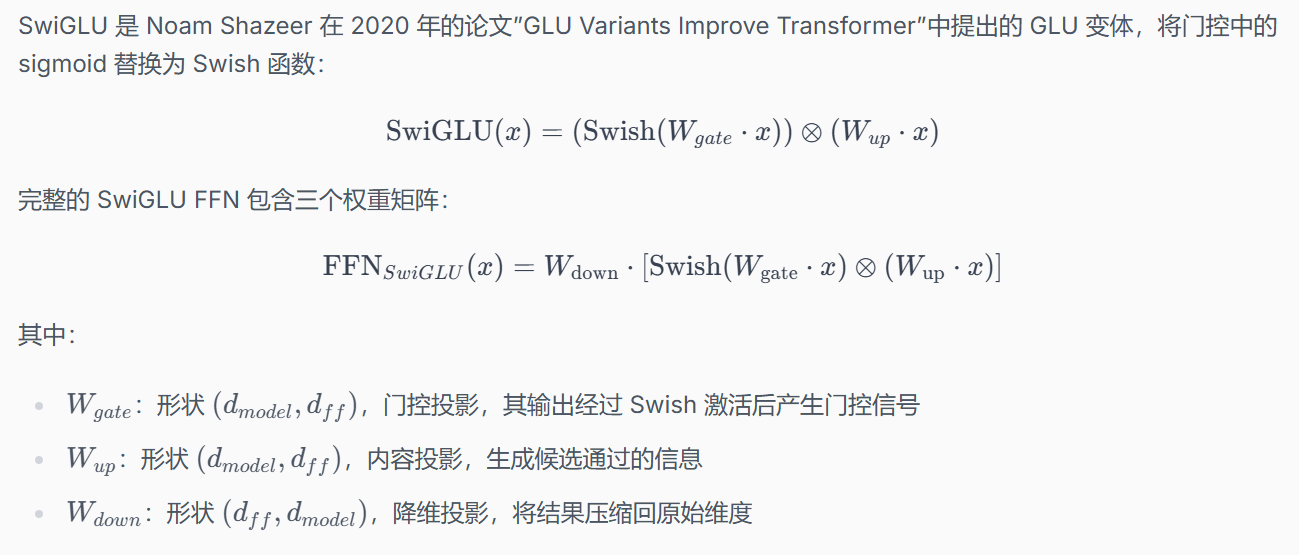

In [ ]:
class SwiGLU(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SwiGLU, self).__init__()
        # gate 分支：决定哪些信息更重要
        self.gate = nn.Linear(input_dim, hidden_dim)
        # up 分支：提供需要被筛选的特征
        self.up = nn.Linear(input_dim, hidden_dim)
        # down 分支：把融合后的特征映射回原始维度
        self.down = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # gate 分支生成“门控信号”
        gate = F.silu(self.gate(x))
        # up 分支生成“内容特征”
        up = self.up(x)
        # gate 和 up 相乘后，再通过 down 输出
        return self.down(gate * up)

In [ ]:
class SwiGLU_MLP(nn.Module):
    def __init__(self, hidden_size: int, intermediate_size: int):
        super().__init__()
        # ==========================================
        # TODO 3: 定义工业级 SwiGLU 的投影矩阵
        # ==========================================
        # self.gate_up_proj = ???
        # self.down_proj = ???
        self.gate_up_proj = nn.Linear(hidden_size, 2 * intermediate_size, bias=False)
        self.down_proj = nn.Linear(intermediate_size, hidden_size, bias=False)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ==========================================
        # TODO 4: 组装工业级 SwiGLU 前向传播
        # ==========================================
        # output = ???
        gate_up = self.gate_up_proj(x)
        gate, up = torch.chunk(gate_up, 2, dim=-1)
        return self.down_proj(gate * up)
